In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
import os
print(os.getcwd())

C:\Users\HP


In [3]:
#import database / data

import sqlite3
import pandas as pd
conn = sqlite3.connect('C:/Users/HP/Downloads/banking_dataset_kaggle/data/database/bank_sqlite.db')

sql_query = """
        SELECT name 
        FROM sqlite_master
        WHERE type='table'

"""

table = pd.read_sql(sql_query, conn)
print(table)

# convert table in dataframe 
for table_name in table['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close() 



           name
0      accounts
1      branches
2         cards
3     customers
4         loans
5     merchants
6  transactions
Created dataframe: df_accounts
Created dataframe: df_branches
Created dataframe: df_cards
Created dataframe: df_customers
Created dataframe: df_loans
Created dataframe: df_merchants
Created dataframe: df_transactions


In [4]:
#print table name and column name
conn = sqlite3.connect('C:/Users/HP/Downloads/banking_dataset_kaggle/data/database/bank_sqlite.db')

for table_name in table['name']:
    print(f"\nTable Name: {table_name}")
    #Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("columns:")
    print(columns['name'].tolist())

conn.close() 
    


Table Name: accounts
columns:
['account_id', 'customer_id', 'account_type', 'balance_usd', 'open_date']

Table Name: branches
columns:
['branch_id', 'branch_name', 'manager_name', 'city', 'country']

Table Name: cards
columns:
['card_id', 'account_id', 'card_type', 'expiration_date']

Table Name: customers
columns:
['customer_id', 'first_name', 'last_name', 'email', 'city', 'credit_score', 'created_at']

Table Name: loans
columns:
['loan_id', 'customer_id', 'loan_amount', 'interest_rate', 'start_date']

Table Name: merchants
columns:
['merchant_id', 'merchant_name', 'city']

Table Name: transactions
columns:
['transaction_id', 'account_id', 'merchant_id', 'amount_usd', 'transaction_date']


In [5]:
df_accounts.head()

,account_id,customer_id,account_type,balance_usd,open_date
0,ACC000NV80W3W25,CUSEU25WUTM7HK9,Checking,27307.96,2022-03-17 08:31:20
1,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25
2,ACC002XR7B6XDZS,CUSZ6YW1EL8RT7P,Business,50462.17,2021-07-14 08:43:28
3,ACC003O7MY9B1ZN,CUSRPHL7ZTPEAXW,Checking,35793.36,2025-01-19 12:33:15
4,ACC003R49JACSPQ,CUSHX3KW6F31CBE,Checking,127048.71,2019-03-16 11:05:54


In [6]:
df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    75000 non-null  object 
 1   customer_id   75000 non-null  object 
 2   account_type  75000 non-null  object 
 3   balance_usd   75000 non-null  float64
 4   open_date     75000 non-null  object 
dtypes: float64(1), object(4)
memory usage: 2.9+ MB


In [7]:
#Rename column name
df_accounts.rename(columns = {'customer_id' : 'customerid'}, inplace= True)
df_accounts


,account_id,customerid,account_type,balance_usd,open_date
0,ACC000NV80W3W25,CUSEU25WUTM7HK9,Checking,27307.96,2022-03-17 08:31:20
1,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25
2,ACC002XR7B6XDZS,CUSZ6YW1EL8RT7P,Business,50462.17,2021-07-14 08:43:28
3,ACC003O7MY9B1ZN,CUSRPHL7ZTPEAXW,Checking,35793.36,2025-01-19 12:33:15
4,ACC003R49JACSPQ,CUSHX3KW6F31CBE,Checking,127048.71,2019-03-16 11:05:54
...,...,...,...,...,...
74995,ACCZZWXZ1WGTXSZ,CUSEP7IUEN6D37A,Checking,66960.41,2020-11-06 17:36:27
74996,ACCZZX8N96SFZM7,CUSU8U5GHQAAKB9,Checking,143410.00,2024-06-14 22:30:55
74997,ACCZZXFHIXU3S2Y,CUSABG8HAO4W128,Business,100185.85,2023-02-08 07:44:50
74998,ACCZZXM1EICPCX0,CUSTBVP9QNDGPLL,Checking,124248.15,2024-01-10 15:19:41


In [8]:
#drop columns
df_accounts.drop(df_accounts.columns[-1:], axis = 1)

,account_id,customerid,account_type,balance_usd
0,ACC000NV80W3W25,CUSEU25WUTM7HK9,Checking,27307.96
1,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62
2,ACC002XR7B6XDZS,CUSZ6YW1EL8RT7P,Business,50462.17
3,ACC003O7MY9B1ZN,CUSRPHL7ZTPEAXW,Checking,35793.36
4,ACC003R49JACSPQ,CUSHX3KW6F31CBE,Checking,127048.71
...,...,...,...,...
74995,ACCZZWXZ1WGTXSZ,CUSEP7IUEN6D37A,Checking,66960.41
74996,ACCZZX8N96SFZM7,CUSU8U5GHQAAKB9,Checking,143410.00
74997,ACCZZXFHIXU3S2Y,CUSABG8HAO4W128,Business,100185.85
74998,ACCZZXM1EICPCX0,CUSTBVP9QNDGPLL,Checking,124248.15


In [9]:
df_accounts.drop(columns=['customer_id'], inplace= True, errors='ignore')
df_accounts.columns

Index(['account_id', 'customerid', 'account_type', 'balance_usd', 'open_date'], dtype='object')

In [10]:
#change data type
df_accounts['open_date'] = pd.to_datetime(df_accounts['open_date'])
df_accounts

,account_id,customerid,account_type,balance_usd,open_date
0,ACC000NV80W3W25,CUSEU25WUTM7HK9,Checking,27307.96,2022-03-17 08:31:20
1,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25
2,ACC002XR7B6XDZS,CUSZ6YW1EL8RT7P,Business,50462.17,2021-07-14 08:43:28
3,ACC003O7MY9B1ZN,CUSRPHL7ZTPEAXW,Checking,35793.36,2025-01-19 12:33:15
4,ACC003R49JACSPQ,CUSHX3KW6F31CBE,Checking,127048.71,2019-03-16 11:05:54
...,...,...,...,...,...
74995,ACCZZWXZ1WGTXSZ,CUSEP7IUEN6D37A,Checking,66960.41,2020-11-06 17:36:27
74996,ACCZZX8N96SFZM7,CUSU8U5GHQAAKB9,Checking,143410.00,2024-06-14 22:30:55
74997,ACCZZXFHIXU3S2Y,CUSABG8HAO4W128,Business,100185.85,2023-02-08 07:44:50
74998,ACCZZXM1EICPCX0,CUSTBVP9QNDGPLL,Checking,124248.15,2024-01-10 15:19:41


In [11]:
df_accounts['open_date'].dt.year.head()

0    2022
1    2021
2    2021
3    2025
4    2019
Name: open_date, dtype: int32

In [12]:
#unique value
df_merchants.head()


,merchant_id,merchant_name,city
0,MER008Y63JK0BUX,Gregory-Meyer,Port Cindy
1,MER00BRU6D2NHTI,"Randall, Gibbs and Dennis",Davidmouth
2,MER00C6HH0ULQQD,Clayton Inc,Port Kevinbury
3,MER00CEA2H7VS72,"Baker, Michael and Burns",West Tyler
4,MER00GJVJ7OGPL9,Owens Group,South Markport


In [13]:
df_merchants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   merchant_id    5000 non-null   object
 1   merchant_name  5000 non-null   object
 2   city           5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


In [14]:
df_merchants['city'].unique()

array(['Port Cindy', 'Davidmouth', 'Port Kevinbury', ..., 'Wesleyview',
       'Medinaland', 'Lake Kimberg'], dtype=object)

In [15]:
df_branches.head()

,branch_id,branch_name,manager_name,city,country
0,BRN01ZNN78I3V3D,East Nicholas Branch,Diane Larson,None,None
1,BRN0307FBDU2Q4K,North Dustin Branch,Mary Hernandez,None,None
2,BRN045ZQQK60738,South Reginald Branch,Susan Spencer,None,None
3,BRN0585SDS271EC,North Amber Branch,Bruce Chapman,None,None
4,BRN06FSFLBAAHKI,Lake Kimberly Branch,Melissa Fleming,None,None


In [16]:
df_branches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   branch_id     500 non-null    object
 1   branch_name   500 non-null    object
 2   manager_name  500 non-null    object
 3   city          0 non-null      object
 4   country       0 non-null      object
dtypes: object(5)
memory usage: 19.7+ KB


In [17]:
#fix missing value
df_branches.isnull().sum()

branch_id         0
branch_name       0
manager_name      0
city            500
country         500
dtype: int64

In [18]:
df_branches['city'].fillna('pune')

0      pune
1      pune
2      pune
3      pune
4      pune
       ... 
495    pune
496    pune
497    pune
498    pune
499    pune
Name: city, Length: 500, dtype: object

In [19]:
df_cards.head()


,card_id,account_id,card_type,expiration_date
0,CRD0007KTMZ0JSO,ACCN5N48WL6P2UZ,Debit,2026-07-15 16:59:18
1,CRD000BUIY8MFPF,ACCVU9XUOTUDLFV,Credit,2026-12-08 22:28:44
2,CRD000MH8E2Y75K,ACC31PXQ5PJK176,Credit,2032-08-27 17:33:50
3,CRD000S4ZG8YOT3,ACCEFW90DPEW1PB,Credit,2030-05-22 05:51:50
4,CRD000XNEHXVSCY,ACC753FVANQPA05,Debit,2025-12-08 14:25:45


In [20]:
df_cards['expiration_date'] = pd.to_datetime(df_cards['expiration_date'])
print(df_cards)

               card_id       account_id card_type     expiration_date
0      CRD0007KTMZ0JSO  ACCN5N48WL6P2UZ     Debit 2026-07-15 16:59:18
1      CRD000BUIY8MFPF  ACCVU9XUOTUDLFV    Credit 2026-12-08 22:28:44
2      CRD000MH8E2Y75K  ACC31PXQ5PJK176    Credit 2032-08-27 17:33:50
3      CRD000S4ZG8YOT3  ACCEFW90DPEW1PB    Credit 2030-05-22 05:51:50
4      CRD000XNEHXVSCY  ACC753FVANQPA05     Debit 2025-12-08 14:25:45
...                ...              ...       ...                 ...
99995  CRDZZXM5MSLAP2M  ACCI4EWIBZKQATX    Credit 2031-12-30 14:21:53
99996  CRDZZY84F0TERR0  ACCPXYBJ9BFKDJS     Debit 2030-12-06 02:40:00
99997  CRDZZYGADHV9DSU  ACCWVE50XPI3RP4     Debit 2032-02-24 17:05:45
99998  CRDZZYM8O19X9WP  ACCO5F9VU40AEYT    Credit 2025-09-01 00:02:39
99999  CRDZZZA81KNQU8G  ACCBA2M4M88NF65    Credit 2027-11-30 09:30:00

[100000 rows x 4 columns]


In [21]:
# Reference date = aaj ki date
reference_date = pd.Timestamp.today()
print(reference_date)

2026-08-25 13:15:30.660560


In [22]:
#Feature engineering and Data analytics -- churn flag

import numpy as np
df_cards['churn_flag'] = np.where(df_cards['expiration_date']< reference_date,1, 0)
print(df_cards['churn_flag'].value_counts())


churn_flag
0    79321
1    20679
Name: count, dtype: int64


In [23]:
#merge

df_merged = (df_accounts
    .merge(df_transactions, on='account_id', how='left')
    .merge(df_cards, on='account_id', how='left'))

print(df_merged.head())

        account_id       customerid account_type  balance_usd  \
0  ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   
1  ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   
2  ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   
3  ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   
4  ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   

            open_date     transaction_id      merchant_id  amount_usd  \
0 2022-03-17 08:31:20  TXN2H7LVB6NAVYHIQ  MERH7IXO3FCHODW     8170.59   
1 2022-03-17 08:31:20  TXN8QSILXEJG5C9L8  MERP6K7ZBQRCPHV     4531.67   
2 2022-03-17 08:31:20  TXNA7H20G3OOQX3MS  MER0Z8J9LJAC3CN     6271.57   
3 2022-03-17 08:31:20  TXNF01ASHMMS4OAXM  MER6UOB80UTMO9F     5771.19   
4 2022-03-17 08:31:20  TXNFVCMCKCJOYR71Y  MERBOKABBS5201L     2971.59   

      transaction_date card_id card_type expiration_date  churn_flag  
0  2025-07-03 10:29:22     NaN       NaN             NaT         NaN  
1  2022-01-01 17:39:59     N

In [24]:

df_merged.shape

(1598705, 13)

In [25]:
df.shape

(1000000, 5)

In [26]:
df.head()

,transaction_id,account_id,merchant_id,amount_usd,transaction_date
0,TXN00005HFWN2XNY3,ACCP1YZO9D6NWHS,MER1ECHZUV9E1WF,9239.92,2022-01-14 04:58:46
1,TXN00009897MR3AF0,ACC39NBWQ11B0YW,MERBTO90OBMKTWM,8261.44,2021-02-20 00:12:15
2,TXN0002DXC6LENBZN,ACCVEP6O0JTRPHJ,MERI68JP0JLHMNF,127.38,2024-06-02 11:20:37
3,TXN0003B7W0PHYMBL,ACC9DAR8N097DNX,MERN7Z2NR7VK3E6,501.59,2020-03-08 22:36:55
4,TXN0003LEFVFA0V95,ACCNULMR5ZNMBK9,MER5284SUXHD16Q,1535.35,2024-09-01 06:49:37


In [27]:
#Data Analysis
#1. Churn rate
df.columns

Index(['transaction_id', 'account_id', 'merchant_id', 'amount_usd',
       'transaction_date'],
      dtype='object')

In [28]:
df_cards.head()

,card_id,account_id,card_type,expiration_date,churn_flag
0,CRD0007KTMZ0JSO,ACCN5N48WL6P2UZ,Debit,2026-07-15 16:59:18,1
1,CRD000BUIY8MFPF,ACCVU9XUOTUDLFV,Credit,2026-12-08 22:28:44,0
2,CRD000MH8E2Y75K,ACC31PXQ5PJK176,Credit,2032-08-27 17:33:50,0
3,CRD000S4ZG8YOT3,ACCEFW90DPEW1PB,Credit,2030-05-22 05:51:50,0
4,CRD000XNEHXVSCY,ACC753FVANQPA05,Debit,2025-12-08 14:25:45,1


In [29]:
df_cards['churn_flag'].mean()*100

20.679

In [30]:
df.head(2)

,transaction_id,account_id,merchant_id,amount_usd,transaction_date
0,TXN00005HFWN2XNY3,ACCP1YZO9D6NWHS,MER1ECHZUV9E1WF,9239.92,2022-01-14 04:58:46
1,TXN00009897MR3AF0,ACC39NBWQ11B0YW,MERBTO90OBMKTWM,8261.44,2021-02-20 00:12:15


In [31]:
#3. churn by card type
churn_by_plan = (df_cards.groupby('card_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  card_type  churn_rate_pct
0    Credit           20.63
1     Debit           20.72


In [32]:
#4. Average amount_usd per transaction_id
arpt = df_transactions['amount_usd'].mean()
print('arpt = ', round(arpt,2))

arpt =  5001.16


In [33]:
#5. Revenue at risk
#merge transaction data with cards
df_merged = df_transactions.merge(df_cards[['account_id', 'churn_flag']], on='account_id', how='left')
print(df_merged)

            transaction_id       account_id      merchant_id  amount_usd  \
0        TXN00005HFWN2XNY3  ACCP1YZO9D6NWHS  MER1ECHZUV9E1WF     9239.92   
1        TXN00009897MR3AF0  ACC39NBWQ11B0YW  MERBTO90OBMKTWM     8261.44   
2        TXN00009897MR3AF0  ACC39NBWQ11B0YW  MERBTO90OBMKTWM     8261.44   
3        TXN0002DXC6LENBZN  ACCVEP6O0JTRPHJ  MERI68JP0JLHMNF      127.38   
4        TXN0002DXC6LENBZN  ACCVEP6O0JTRPHJ  MERI68JP0JLHMNF      127.38   
...                    ...              ...              ...         ...   
1598700  TXNZZZI1W8UF7E92B  ACC03ODR9VWK2NY  MERT5OB64AUCW9K     2641.39   
1598701  TXNZZZI65GWISG6ZS  ACCGRTSRXFMYHVO  MERNM2UO3KNSOAL     2512.64   
1598702  TXNZZZQZQMJHHSGNU  ACCEEJ8II1F36UL  MERPGCEHD3RI6U6     9950.07   
1598703  TXNZZZXI5FW6Z7LO2  ACCCEOAW1BS26VT  MERD893U61KI480     3048.53   
1598704  TXNZZZXI5FW6Z7LO2  ACCCEOAW1BS26VT  MERD893U61KI480     3048.53   

            transaction_date  churn_flag  
0        2022-01-14 04:58:46         NaN  
1

In [34]:
total_revenue = df_merged['amount_usd'].sum()
revenue_at_risk = df_merged.loc[df_merged['churn_flag']==1, 'amount_usd'].sum()
revenue_pct = (revenue_at_risk / total_revenue) * 100
print(revenue_pct)


17.24502973562964


In [35]:
#6. mean of amount usd
mean = df_merged['amount_usd'].mean()
total = df_merged['amount_usd'].sum()
pct = (mean/total)*100
print(pct)

6.255062691365825e-05


In [36]:
#7. Correlation amount_usd vs churn_flag
correlation = df_merged['amount_usd'].corr(df_merged['churn_flag'])
correlation

-0.0015518416906324238

In [37]:
#8. Merge data for finding balance usd vs  churn_flag
df_merged = df_accounts.merge(df_cards[['account_id', 'churn_flag']], on='account_id', how='left')
print(df_merged)

             account_id       customerid account_type  balance_usd  \
0       ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   
1       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
2       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
3       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
4       ACC002XR7B6XDZS  CUSZ6YW1EL8RT7P     Business     50462.17   
...                 ...              ...          ...          ...   
119887  ACCZZXM1EICPCX0  CUSTBVP9QNDGPLL     Checking    124248.15   
119888  ACCZZXM1EICPCX0  CUSTBVP9QNDGPLL     Checking    124248.15   
119889  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
119890  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
119891  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   

                 open_date  churn_flag  
0      2022-03-17 08:31:20         NaN  
1      2021-10-28 12:55:25         0.0  
2      2021-10-28 12:55:25         0

In [38]:
correlation = df_merged['balance_usd'].corr(df_merged['churn_flag'])
correlation

0.004003067001494354

In [39]:
df_merged.head()

,account_id,customerid,account_type,balance_usd,open_date,churn_flag
0,ACC000NV80W3W25,CUSEU25WUTM7HK9,Checking,27307.96,2022-03-17 08:31:20,NaN
1,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0
2,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0
3,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0
4,ACC002XR7B6XDZS,CUSZ6YW1EL8RT7P,Business,50462.17,2021-07-14 08:43:28,NaN


In [40]:
df_customers.rename(columns = {'customer_id' : 'customerid'}, inplace= True)
df_customers

,customerid,first_name,last_name,email,city,credit_score,created_at
0,CUS000MKX5RHTAP,Abigail,Ashley,ruthwilliams@example.com,South Christopherton,827,2025-12-30 00:22:11
1,CUS002V4AVJO5UQ,Ralph,Obrien,brooke20@example.com,North Michaelport,510,2019-09-13 07:46:29
2,CUS004THQ8NDQW3,Andres,Stevens,robertsbenjamin@example.com,Port Faithstad,636,2024-01-01 18:57:58
3,CUS007GCM2J726A,Jessica,Davis,williamshaley@example.org,Lake Blaketown,492,2024-04-29 23:10:15
4,CUS00AO13A3Q5FO,Nicole,Murray,mendozajoshua@example.net,Sheriside,686,2019-05-27 09:28:46
...,...,...,...,...,...,...,...
49995,CUSZZW4UXJM5YPH,John,Jackson,qanderson@example.net,North Shawnville,564,2023-10-22 14:40:51
49996,CUSZZX0GSKOD504,Shannon,Walsh,harmongeorge@example.org,North David,780,2019-04-07 11:46:23
49997,CUSZZY7PESEDALL,Scott,Smith,vanessaholmes@example.com,North Karenmouth,788,2024-11-27 05:00:28
49998,CUSZZZ9PRCCSILX,Jose,Perkins,lopezjulie@example.com,South Phillipburgh,644,2024-10-16 20:58:35


In [41]:
#9. Merge data for finding corrleation between credit score vs churn_flag 
df_merge = df_merged.merge(df_customers[['credit_score', 'customerid']], on='customerid', how='left')
print(df_merge)

             account_id       customerid account_type  balance_usd  \
0       ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   
1       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
2       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
3       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
4       ACC002XR7B6XDZS  CUSZ6YW1EL8RT7P     Business     50462.17   
...                 ...              ...          ...          ...   
119887  ACCZZXM1EICPCX0  CUSTBVP9QNDGPLL     Checking    124248.15   
119888  ACCZZXM1EICPCX0  CUSTBVP9QNDGPLL     Checking    124248.15   
119889  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
119890  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
119891  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   

                 open_date  churn_flag  credit_score  
0      2022-03-17 08:31:20         NaN           313  
1      2021-10-28 12:55:25         0.0           

In [42]:
#10. corrleation between credit_score and churn_flag
correlation = df_merge['credit_score'].corr(df_merge['churn_flag'])
correlation

-0.0015113422023954872

In [43]:
#11. visualization using matplotlib
df_visual = df.copy()

In [44]:
df_visual.columns

Index(['transaction_id', 'account_id', 'merchant_id', 'amount_usd',
       'transaction_date'],
      dtype='object')

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [46]:
#merge data with churn_flag
df_merge_visual = df_visual.merge(df_merge[['account_id', 'churn_flag']], on='account_id', how='left')
print(df_merge_visual)

            transaction_id       account_id      merchant_id  amount_usd  \
0        TXN00005HFWN2XNY3  ACCP1YZO9D6NWHS  MER1ECHZUV9E1WF     9239.92   
1        TXN00009897MR3AF0  ACC39NBWQ11B0YW  MERBTO90OBMKTWM     8261.44   
2        TXN00009897MR3AF0  ACC39NBWQ11B0YW  MERBTO90OBMKTWM     8261.44   
3        TXN0002DXC6LENBZN  ACCVEP6O0JTRPHJ  MERI68JP0JLHMNF      127.38   
4        TXN0002DXC6LENBZN  ACCVEP6O0JTRPHJ  MERI68JP0JLHMNF      127.38   
...                    ...              ...              ...         ...   
1598700  TXNZZZI1W8UF7E92B  ACC03ODR9VWK2NY  MERT5OB64AUCW9K     2641.39   
1598701  TXNZZZI65GWISG6ZS  ACCGRTSRXFMYHVO  MERNM2UO3KNSOAL     2512.64   
1598702  TXNZZZQZQMJHHSGNU  ACCEEJ8II1F36UL  MERPGCEHD3RI6U6     9950.07   
1598703  TXNZZZXI5FW6Z7LO2  ACCCEOAW1BS26VT  MERD893U61KI480     3048.53   
1598704  TXNZZZXI5FW6Z7LO2  ACCCEOAW1BS26VT  MERD893U61KI480     3048.53   

            transaction_date  churn_flag  
0        2022-01-14 04:58:46         NaN  
1

In [47]:
#convert transaction date to date time
df_merge_visual['transaction_date'] = pd.to_datetime(df_merge_visual['transaction_date'])
print(df_merge_visual)

            transaction_id       account_id      merchant_id  amount_usd  \
0        TXN00005HFWN2XNY3  ACCP1YZO9D6NWHS  MER1ECHZUV9E1WF     9239.92   
1        TXN00009897MR3AF0  ACC39NBWQ11B0YW  MERBTO90OBMKTWM     8261.44   
2        TXN00009897MR3AF0  ACC39NBWQ11B0YW  MERBTO90OBMKTWM     8261.44   
3        TXN0002DXC6LENBZN  ACCVEP6O0JTRPHJ  MERI68JP0JLHMNF      127.38   
4        TXN0002DXC6LENBZN  ACCVEP6O0JTRPHJ  MERI68JP0JLHMNF      127.38   
...                    ...              ...              ...         ...   
1598700  TXNZZZI1W8UF7E92B  ACC03ODR9VWK2NY  MERT5OB64AUCW9K     2641.39   
1598701  TXNZZZI65GWISG6ZS  ACCGRTSRXFMYHVO  MERNM2UO3KNSOAL     2512.64   
1598702  TXNZZZQZQMJHHSGNU  ACCEEJ8II1F36UL  MERPGCEHD3RI6U6     9950.07   
1598703  TXNZZZXI5FW6Z7LO2  ACCCEOAW1BS26VT  MERD893U61KI480     3048.53   
1598704  TXNZZZXI5FW6Z7LO2  ACCCEOAW1BS26VT  MERD893U61KI480     3048.53   

           transaction_date  churn_flag  
0       2022-01-14 04:58:46         NaN  
1  

In [48]:
#create month column
df_merge_visual['month'] = df_merge_visual['transaction_date'].dt.to_period('M')
print(df_merge_visual['month'])

0          2022-01
1          2021-02
2          2021-02
3          2024-06
4          2024-06
            ...   
1598700    2022-06
1598701    2020-12
1598702    2024-02
1598703    2021-11
1598704    2021-11
Name: month, Length: 1598705, dtype: period[M]


In [49]:
#create churn trend
churn_trend = df_merge_visual[df_merge_visual['churn_flag'] == 1].groupby('month').size()
print(churn_trend.shape)


(84,)


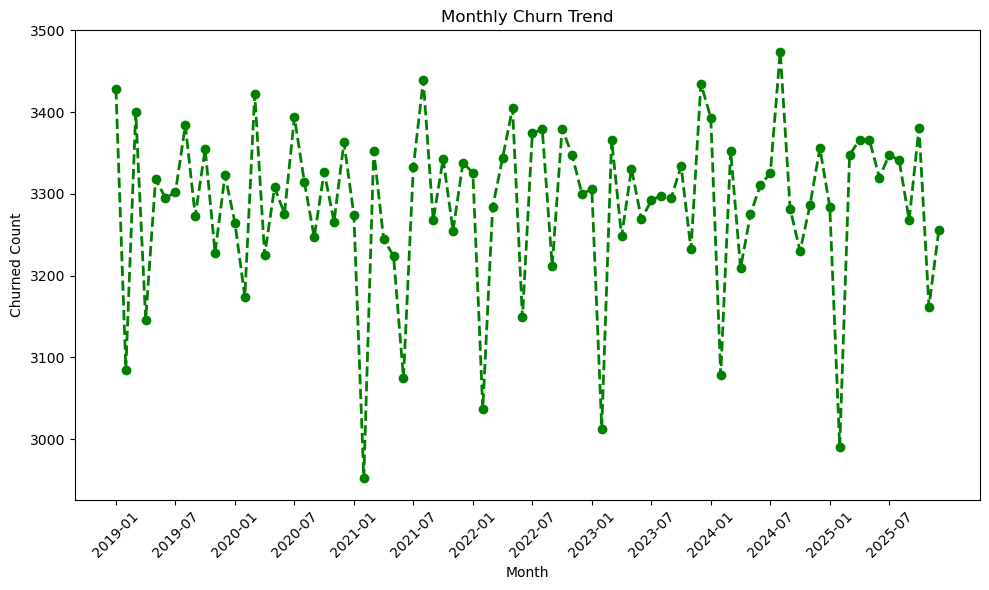

In [50]:
#Visualization plot
x = churn_trend.index.astype(str)
y = churn_trend.values

plt.figure(figsize=(10,6))
plt.plot(x,y, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=6)

# Sirf har 6th ya 12th label dikhao, sab nahi
plt.xticks(ticks=range(0, len(x), 6), labels=x[::6], rotation=45)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Count')
plt.tight_layout()
plt.show()

In [51]:
#churn by card type and plot
churn_plan = df_cards.groupby('card_type')['churn_flag'].mean()
print(churn_plan)

card_type
Credit    0.206337
Debit     0.207243
Name: churn_flag, dtype: float64


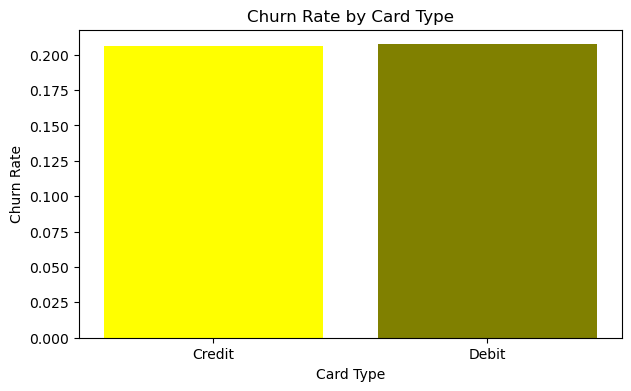

In [52]:
#plot churn by card_type
colors = ['yellow', 'olive']
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title('Churn Rate by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Churn Rate')
plt.show()

In [53]:
#12. Visualization using seaborn
#Heatmap (correlation matrix)
#1. Encoding 
df_merge_visual.columns

Index(['transaction_id', 'account_id', 'merchant_id', 'amount_usd',
       'transaction_date', 'churn_flag', 'month'],
      dtype='object')

In [54]:
df_encoded = df_merge_visual[['transaction_id', 'account_id', 'merchant_id', 'amount_usd',
                                'transaction_date', 'churn_flag', 'month']]
     

In [55]:
df_encoded.head()

,transaction_id,account_id,merchant_id,amount_usd,transaction_date,churn_flag,month
0,TXN00005HFWN2XNY3,ACCP1YZO9D6NWHS,MER1ECHZUV9E1WF,9239.92,2022-01-14 04:58:46,NaN,2022-01
1,TXN00009897MR3AF0,ACC39NBWQ11B0YW,MERBTO90OBMKTWM,8261.44,2021-02-20 00:12:15,0.0,2021-02
2,TXN00009897MR3AF0,ACC39NBWQ11B0YW,MERBTO90OBMKTWM,8261.44,2021-02-20 00:12:15,0.0,2021-02
3,TXN0002DXC6LENBZN,ACCVEP6O0JTRPHJ,MERI68JP0JLHMNF,127.38,2024-06-02 11:20:37,0.0,2024-06
4,TXN0002DXC6LENBZN,ACCVEP6O0JTRPHJ,MERI68JP0JLHMNF,127.38,2024-06-02 11:20:37,1.0,2024-06


In [56]:
# 1. NaN fix karo churn_flag me
df_encoded['churn_flag'] = df_encoded['churn_flag'].fillna(0)
print(df_encoded['churn_flag'])

0          0.0
1          0.0
2          0.0
3          0.0
4          1.0
          ... 
1598700    0.0
1598701    0.0
1598702    0.0
1598703    0.0
1598704    0.0
Name: churn_flag, Length: 1598705, dtype: float64


In [57]:
# 2. month convert to numeric (Period type ko int me convert)
df_encoded['month'] = df_encoded['month'].astype(str).str.replace('-', '').astype(int)
print(df_encoded['month'])

0          202201
1          202102
2          202102
3          202406
4          202406
            ...  
1598700    202206
1598701    202012
1598702    202402
1598703    202111
1598704    202111
Name: month, Length: 1598705, dtype: int32


In [58]:
# 3. ID and date columns drop - inka correlation matrix me koi use nahi
df_corr = df_encoded.drop(columns=['transaction_id', 'account_id', 'merchant_id', 'transaction_date'])
print(df_corr)

         amount_usd  churn_flag   month
0           9239.92         0.0  202201
1           8261.44         0.0  202102
2           8261.44         0.0  202102
3            127.38         0.0  202406
4            127.38         1.0  202406
...             ...         ...     ...
1598700     2641.39         0.0  202206
1598701     2512.64         0.0  202012
1598702     9950.07         0.0  202402
1598703     3048.53         0.0  202111
1598704     3048.53         0.0  202111

[1598705 rows x 3 columns]


In [59]:
# 4. correlation matrix create
corr_matrix = df_corr.corr()
print(corr_matrix)

            amount_usd  churn_flag     month
amount_usd    1.000000   -0.001378  0.000618
churn_flag   -0.001378    1.000000 -0.000046
month         0.000618   -0.000046  1.000000


<Axes: >

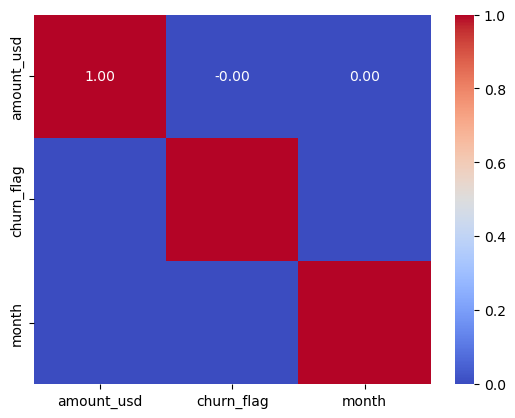

In [60]:
import seaborn as sns
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

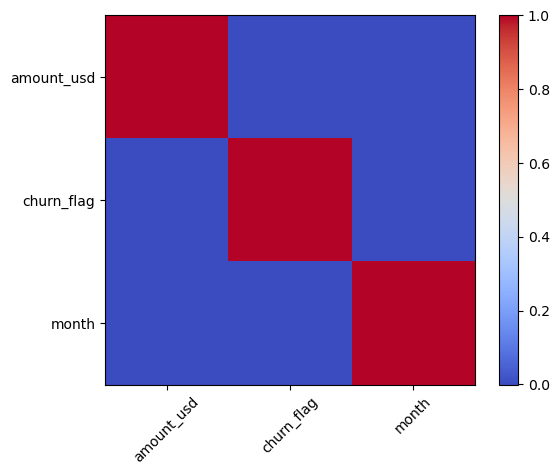

In [61]:
#Heatmap using matplotlib
import matplotlib.pyplot as plt

plt.imshow(df_corr.corr(), cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=45)
plt.yticks(range(len(df_corr.columns)), df_corr.columns)
plt.show()


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


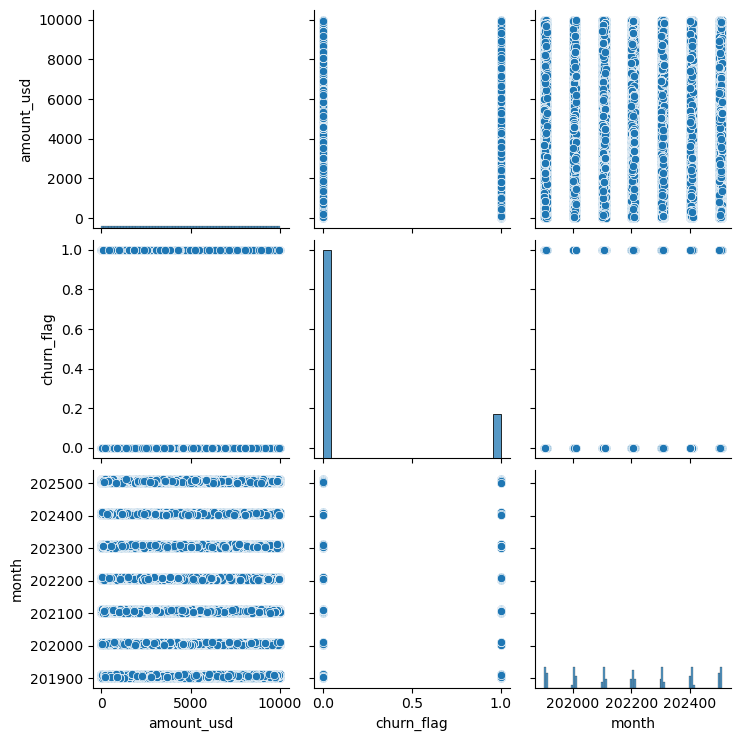

In [62]:
#pairplot - relationship in dataset
sns.pairplot(df_encoded)

In [63]:
df_merge.columns

Index(['account_id', 'customerid', 'account_type', 'balance_usd', 'open_date',
       'churn_flag', 'credit_score'],
      dtype='object')

In [67]:
df_merge.head()

,account_id,customerid,account_type,balance_usd,open_date,churn_flag,credit_score
0,ACC000NV80W3W25,CUSEU25WUTM7HK9,Checking,27307.96,2022-03-17 08:31:20,NaN,313
1,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0,427
2,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0,427
3,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0,427
4,ACC002XR7B6XDZS,CUSZ6YW1EL8RT7P,Business,50462.17,2021-07-14 08:43:28,NaN,426


In [72]:
df_merge['churn_flag'] = df_merge['churn_flag'].fillna(0)
print(df_merge['churn_flag'])

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
119887    1.0
119888    0.0
119889    0.0
119890    0.0
119891    0.0
Name: churn_flag, Length: 119892, dtype: float64


In [73]:
df_merge.head()

,account_id,customerid,account_type,balance_usd,open_date,churn_flag,credit_score
0,ACC000NV80W3W25,CUSEU25WUTM7HK9,Checking,27307.96,2022-03-17 08:31:20,0.0,313
1,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0,427
2,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0,427
3,ACC002FHD9SACSA,CUSLTOG1EPNYETU,Checking,157104.62,2021-10-28 12:55:25,0.0,427
4,ACC002XR7B6XDZS,CUSZ6YW1EL8RT7P,Business,50462.17,2021-07-14 08:43:28,0.0,426


In [79]:
df_card_merge = df_merge.merge(df_cards[['account_id', 'card_type']], on='account_id', how='left')
print(df_card_merge)

             account_id       customerid account_type  balance_usd  \
0       ACC000NV80W3W25  CUSEU25WUTM7HK9     Checking     27307.96   
1       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
2       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
3       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
4       ACC002FHD9SACSA  CUSLTOG1EPNYETU     Checking    157104.62   
...                 ...              ...          ...          ...   
253781  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
253782  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
253783  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
253784  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   
253785  ACCZZYYYTFOFSOU  CUSXJFR7Q42POHV     Business     46134.92   

                 open_date  churn_flag  credit_score card_type  
0      2022-03-17 08:31:20         0.0           313       NaN  
1      2021-10-28 12:55:25   

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


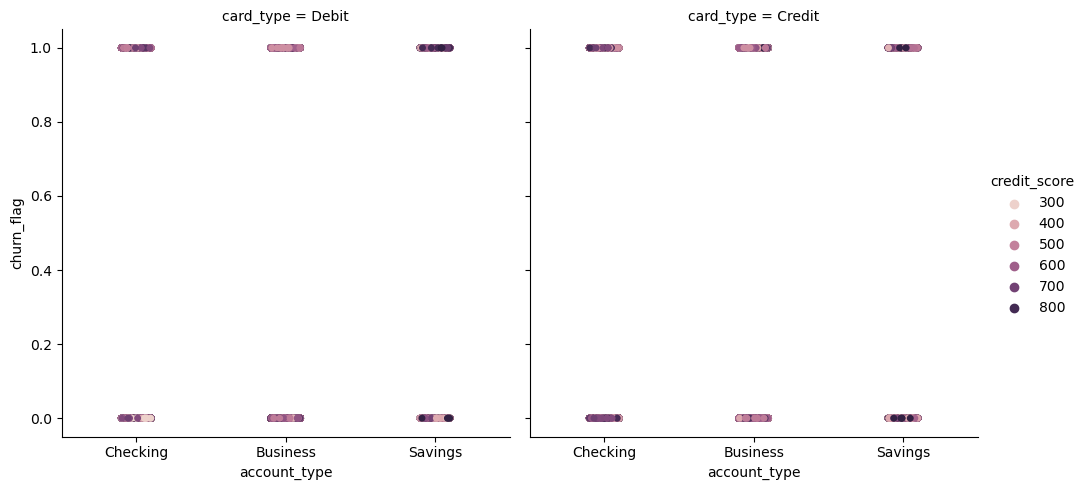

In [81]:
#catplot/ facegrid plot
sns.catplot(data = df_card_merge,
            x='account_type',
            y='churn_flag',
            hue='credit_score',
            col='card_type')

In [82]:
#pivot table
pd.pivot_table(
    df_card_merge,
    index='card_type',
    values=['balance_usd', 'churn_flag', 'credit_score'],
    aggfunc = {
        'balance_usd' : 'nunique',
        'churn_flag' : 'mean',
        'credit_score' : 'sum'
    }
)

,balance_usd,churn_flag,credit_score
card_type,,,
Credit,36349,0.206873,67294244
Debit,36398,0.205997,67174124
